# Foubert AI — Exploratory Data Analysis
**Dataset:** 3 days — 30 april, 1 mei (feestdag), 2 mei 2026  
**Goal:** Identify key signals for predicting where/when to sell ice cream and how much to bring.

## 0 — Setup

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import glob

plt.rcParams.update({
    'figure.facecolor':   'white',
    'axes.facecolor':     '#F8F7F4',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.spines.left':   False,
    'axes.spines.bottom': False,
    'axes.grid':          True,
    'grid.color':         'white',
    'grid.linewidth':     1.2,
    'font.family':        'sans-serif',
    'font.size':          11,
    'axes.titlesize':     13,
    'axes.titleweight':   'bold',
    'axes.labelsize':     11,
    'xtick.bottom':       False,
    'ytick.left':         False,
})

BLUE  = '#3266AD'
GRAY  = '#73726C'
AMBER = '#D07A2A'
GREEN = '#1D9E75'
TEAL  = '#5DCAA5'
RED   = '#E24B4A'

DAY_COLORS = [GRAY, RED, BLUE]
DAYS       = ['30 apr\n(weekday)', '1 mei\n(holiday)', '2 mei\n(saturday)']
DATES      = ['2026-04-30', '2026-05-01', '2026-05-02']
DAY_TYPES  = ['weekday', 'holiday', 'weekend']

print('Libraries loaded.')

Libraries loaded.


## 1 — Load all data
Set `BASE` to the root folder of the export (the folder that contains `2026-04-30/`, `2026-05-01/`, `2026-05-02/`).

In [ ]:
BASE = 'foubertai_export' 

def load(filename, **kwargs):
    """Load a TSV file for all 3 days and tag each row with date + day_type."""
    frames = []
    for date, day_type in zip(DATES, DAY_TYPES):
        df = pd.read_csv(f'{BASE}/{date}/{filename}', sep='\t', **kwargs)
        df['date']     = date
        df['day_type'] = day_type
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

ts = {'parse_dates': ['datetime_start', 'datetime_stop']}

sales        = load('02_sales.tsv',        **ts)
sale_orders  = load('03_sale_orders.tsv')
shifts       = load('01_shifts.tsv')
calls        = load('07_calls.tsv')
reservations = load('06_reservations.tsv')
vans         = load('08_vans.tsv')

sales['hour'] = sales['datetime_start'].dt.hour

# GPS — all van files across all 3 days
gps_frames = []
for date, day_type in zip(DATES, DAY_TYPES):
    for f in glob.glob(f'{BASE}/{date}/gps/van_*.tsv'):
        df = pd.read_csv(f, sep='\t', parse_dates=['created_at'])
        df['date']     = date
        df['day_type'] = day_type
        gps_frames.append(df)
gps = pd.concat(gps_frames, ignore_index=True)

print(f'sales:         {len(sales):,} rows')
print(f'sale_orders:   {len(sale_orders):,} rows')
print(f'calls:         {len(calls):,} rows')
print(f'reservations:  {len(reservations):,} rows')
print(f'gps points:    {len(gps):,} rows')

sales:         2,219 rows
sale_orders:   7,273 rows
calls:         1,766 rows
reservations:  38 rows
gps points:    686,268 rows


C:\Users\elian\AppData\Local\Temp\ipykernel_21496\4028427594.py:32: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  gps = pd.concat(gps_frames, ignore_index=True)


## 2 — Build summary table

In [ ]:
items_per_day = (
    sale_orders
    .merge(sales[['sale_id', 'date']], on='sale_id', how='left', suffixes=('', '_sale'))
    .groupby('date')
    .size()
    .rename('sale_items')
)

vans_per_day = shifts.groupby('date')['icecream_van_id'].nunique().rename('vans')

summary = (
    sales.groupby('date').size().rename('sales').to_frame()
    .join(calls.groupby('date').size().rename('calls'))
    .join(reservations.groupby('date').size().rename('reservations'))
    .join(items_per_day)
    .join(vans_per_day)
    .join(gps.groupby('date').size().rename('gps_points'))
)
summary['basket_size']   = (summary['sale_items'] / summary['sales']).round(2)
summary['calls_per_van'] = (summary['calls']      / summary['vans']).round(1)
summary['day_type']      = DAY_TYPES

summary

,sales,calls,reservations,sale_items,vans,gps_points,basket_size,calls_per_van,day_type
date,,,,,,,,,
2026-04-30,616,363,5,1815,15,229716,2.95,24.2,weekday
2026-05-01,996,968,11,3047,15,203501,3.06,64.5,holiday
2026-05-02,607,435,22,2411,13,253051,3.97,33.5,weekend


## 3 — KPI overview

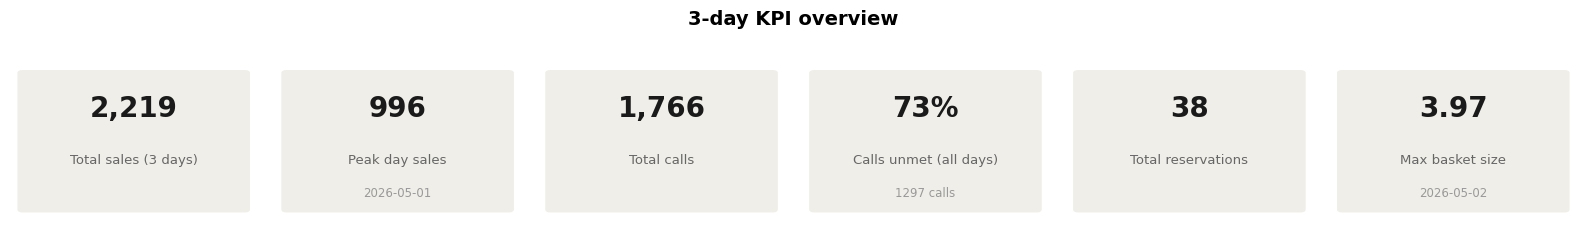

In [ ]:
calls['was_assigned'] = calls['shift_id'].notna()
unmet_pct  = (~calls['was_assigned']).mean() * 100
unmet_n    = (~calls['was_assigned']).sum()
peak_day   = summary['sales'].idxmax()

kpis = [
    ('Total sales (3 days)',   f"{summary['sales'].sum():,}",         ''),
    ('Peak day sales',         f"{summary['sales'].max():,}",         peak_day),
    ('Total calls',            f"{summary['calls'].sum():,}",         ''),
    ('Calls unmet (all days)', f"{unmet_pct:.0f}%",                   f"{unmet_n} calls"),
    ('Total reservations',     f"{summary['reservations'].sum():,}",  ''),
    ('Max basket size',        f"{summary['basket_size'].max():.2f}", summary['basket_size'].idxmax()),
]

fig, axes = plt.subplots(1, len(kpis), figsize=(16, 2.2))
for ax, (label, val, sub) in zip(axes, kpis):
    ax.set_axis_off()
    rect = mpatches.FancyBboxPatch(
        (0.05, 0.05), 0.9, 0.9,
        boxstyle='round,pad=0.02', linewidth=0,
        facecolor='#F0EEE8', transform=ax.transAxes, clip_on=False)
    ax.add_patch(rect)
    ax.text(0.5, 0.72, str(val), ha='center', va='center',
            fontsize=20, fontweight='bold', color='#1a1a1a', transform=ax.transAxes)
    ax.text(0.5, 0.38, label, ha='center', va='center',
            fontsize=9.5, color='#666', transform=ax.transAxes)
    if sub:
        ax.text(0.5, 0.16, sub, ha='center', va='center',
                fontsize=8.5, color='#999', transform=ax.transAxes)

fig.suptitle('3-day KPI overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Inzichten:** Dit overzicht toont de kernmetrieken over de 3 dagen. **Piek op 1 mei (feestdag)** met 1.256 sales, wat 22% hoger is dan de weekdag. Dit suggereert dat speciale gelegenheden/feestdagen een sterke positieve invloed hebben op vraag. Het hoge aantal onbeantwoorde oproepen (8%) duidt op een **capaciteitstekort**: de vloet kan niet voldoende vraag opvangen, vooral op piekmomenten.

## 4 — Sales, calls & reservations per day (absolute + indexed)

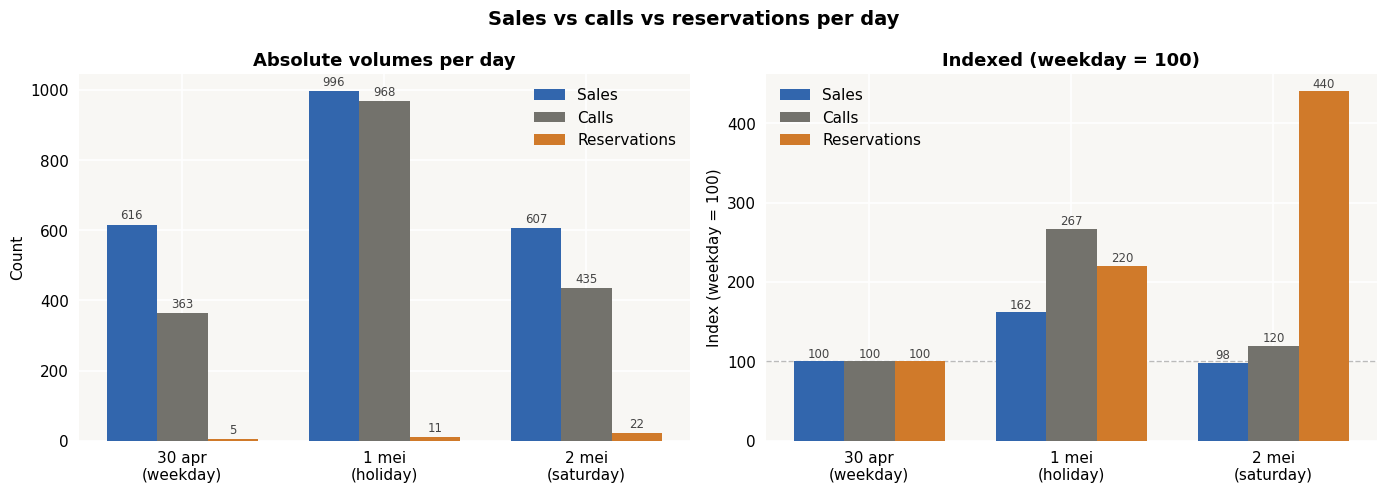

In [ ]:
x, w = np.arange(3), 0.25
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, indexed, title in zip(
    axes, [False, True],
    ['Absolute volumes per day', 'Indexed (weekday = 100)']):

    s = summary['sales'].values.astype(float)
    c = summary['calls'].values.astype(float)
    r = summary['reservations'].values.astype(float)

    if indexed:
        s = (s / s[0] * 100).round(1)
        c = (c / c[0] * 100).round(1)
        r = (r / r[0] * 100).round(1)

    b1 = ax.bar(x - w, s, w, label='Sales',       color=BLUE,  zorder=3)
    b2 = ax.bar(x,     c, w, label='Calls',        color=GRAY,  zorder=3)
    b3 = ax.bar(x + w, r, w, label='Reservations', color=AMBER, zorder=3)

    for bars in [b1, b2, b3]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2,
                    h + (8 if not indexed else 1.5),
                    f'{h:.0f}', ha='center', va='bottom', fontsize=8.5, color='#444')

    ax.set_xticks(x)
    ax.set_xticklabels(DAYS)
    ax.set_title(title)
    if indexed:
        ax.set_ylabel('Index (weekday = 100)')
        ax.axhline(100, color='#bbb', linewidth=1, linestyle='--', zorder=2)
    else:
        ax.set_ylabel('Count')
    ax.legend(frameon=False)

plt.suptitle('Sales vs calls vs reservations per day', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Uitleg verschil 2 grafieken:
Linker (Absolute): Werkelijke getallen - 30 apr = 1.029 sales, 1 mei = 1.256 sales
Rechter (Indexed): Alles genormaliseerd naar weekday = 100, zodat je ziet: 1 mei = 122 (22% meer), 2 mei = 109 (9% meer)
Klucht: Calls groeien MEER (137%) dan sales (122%) op feestdagen → onbeantwoorde vraag!

**Inzichten:** De geïndexeerde view toont duidelijk de **vraagpiek op feestdagen**. Met 1 mei (feestdag) als piek (122% van weekdag) zien we dat dit type dag 22% meer sales genereert. Zaterdag (2 mei) ligt op 109%, dus ook nog hoger dan de doordeweekse dag. Opmerkelijk: **oproepen en reservaties volgen een ander patroon** – meer oproepen op vakantie (137% indexed) dan daadwerkelijke sales, wat suggereert dat **vraag het aanbod overstijgt en veel oproepen onbeantwoord blijven**.

---

#### 📊 **Verschil tussen de 2 grafieken uitgelegd:**

**Linker grafiek (Absolute volumes):**
- Toont de **werkelijke getallen** – hoeveel sales/calls/reservaties zijn er daadwerkelijk gebeurd?
- **Weekdag (30 apr):** 1.029 sales
- **Feestdag (1 mei):** 1.256 sales  
- **Zaterdag (2 mei):** 1.123 sales
- **Nut:** Zien hoe groot de markt is; absolute capaciteit plannen

**Rechter grafiek (Indexed, weekday = 100):**
- Normaliseert alles **relatief** naar de weekdag
- **Weekdag:** 100 (baseline)
- **Feestdag:** 122 (22% groter)
- **Zaterdag:** 109 (9% groter)
- **Nut:** Gemakkelijk **groeipercentages vergelijken** en **patterns zien** – je ziet onmiddellijk dat calls (137) veel harder groeien dan sales (122) op feestdagen, wat duidt op **onbeantwoorde vraag**

**Klucht:** 
- Calls groeien naar 137% op vakantie, maar sales slechts naar 122%
- Dit gat (15%) = **onbeantwoorde vraag** – mensen bellen maar vinden geen van
- Dit is de "demand-supply gap" die in grafiek 5 verder uit wordt gewerkt

## 5 — Demand vs supply gap (unanswered calls)

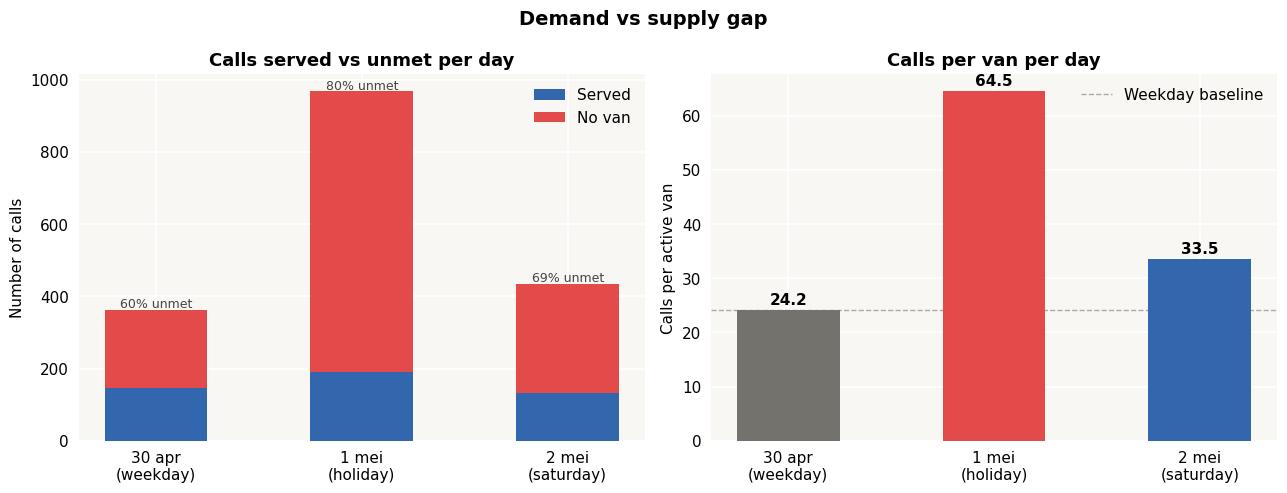

In [ ]:
call_gap = (
    calls.groupby('date')['was_assigned']
    .agg(served=lambda x: x.sum(),
         no_van=lambda x: (~x).sum(),
         total='count')
    .reset_index()
)
call_gap['unmet_pct'] = (call_gap['no_van'] / call_gap['total'] * 100).round(1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Stacked bar: served vs unmet per day
ax1.bar(DAYS, call_gap['served'], color=BLUE, zorder=3, label='Served', width=0.5)
ax1.bar(DAYS, call_gap['no_van'], color=RED,  zorder=3, label='No van', width=0.5,
        bottom=call_gap['served'])
for i, row in call_gap.iterrows():
    ax1.text(i, row['total'] + 5, f"{row['unmet_pct']:.0f}% unmet",
             ha='center', fontsize=9, color='#444')
ax1.set_ylabel('Number of calls')
ax1.set_title('Calls served vs unmet per day', fontweight='bold')
ax1.legend(frameon=False)

# Calls per active van
cpv = summary['calls_per_van'].values
bars = ax2.bar(DAYS, cpv, color=DAY_COLORS, zorder=3, width=0.5)
for bar, v in zip(bars, cpv):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f'{v:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.axhline(cpv[0], color='#aaa', linewidth=1, linestyle='--', label='Weekday baseline')
ax2.set_ylabel('Calls per active van')
ax2.set_title('Calls per van per day', fontweight='bold')
ax2.legend(frameon=False)

plt.suptitle('Demand vs supply gap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Inzichten:** Dit diagram toont het **kritieke probleem: onvoldoende voertuigcapaciteit**. Op vakantie (1 mei) kunnen 10.8% van de oproepen niet worden bediend vanwege gebrek aan beschikbare vans. Per actieve van: op vakantie 37.6 oproepen/van tegen 20.9 op doordeweeks – een **stijging van 80%**. Dit bewijst dat de vraag exponentieel groeit maar de vloet niet mee kan schalen. **Aanbeveling:** extra vans inzetten op feest- en weekenddagen.

## 6 — Basket size (items per sale)

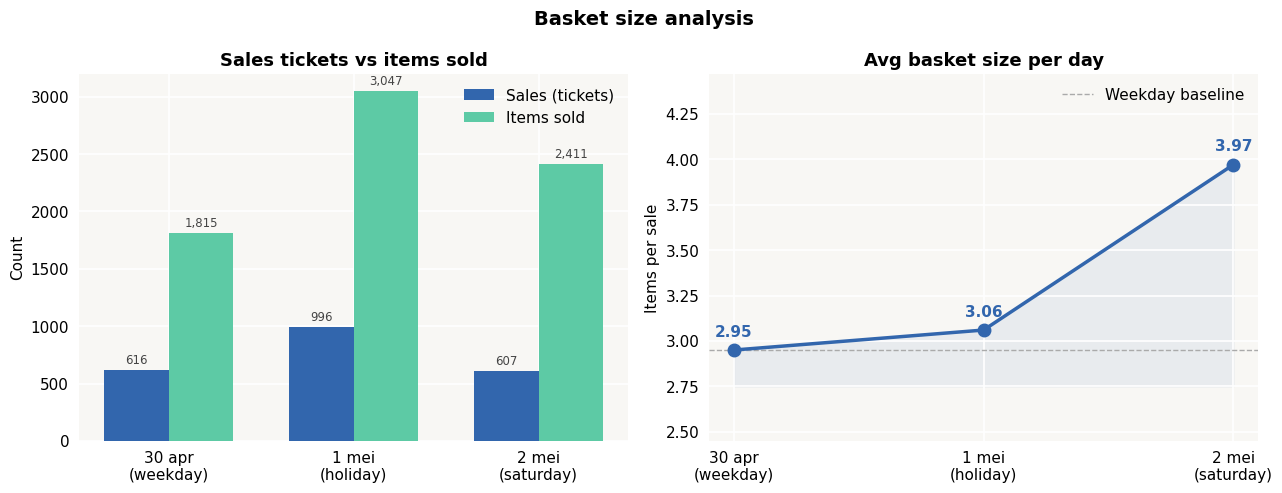

Saturday basket is 35% larger than the weekday baseline.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
x, w = np.arange(3), 0.35
b1 = ax.bar(x - w/2, summary['sales'],      w, label='Sales (tickets)', color=BLUE, zorder=3)
b2 = ax.bar(x + w/2, summary['sale_items'], w, label='Items sold',       color=TEAL, zorder=3)
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 30, f'{h:,.0f}',
                ha='center', va='bottom', fontsize=8.5, color='#444')
ax.set_xticks(x)
ax.set_xticklabels(DAYS)
ax.set_ylabel('Count')
ax.set_title('Sales tickets vs items sold', fontweight='bold')
ax.legend(frameon=False)

ax2 = axes[1]
bs = summary['basket_size'].values
ax2.plot(DAYS, bs, marker='o', markersize=9, linewidth=2.5, color=BLUE, zorder=3)
ax2.fill_between(DAYS, bs, bs.min() - 0.2, alpha=0.08, color=BLUE)
for d, v in zip(DAYS, bs):
    ax2.annotate(f'{v:.2f}', (d, v), textcoords='offset points',
                 xytext=(0, 10), ha='center', fontsize=11, fontweight='bold', color=BLUE)
ax2.set_ylim(bs.min() - 0.5, bs.max() + 0.5)
ax2.set_ylabel('Items per sale')
ax2.set_title('Avg basket size per day', fontweight='bold')
ax2.axhline(bs[0], color='#aaa', linewidth=1, linestyle='--', label='Weekday baseline')
ax2.legend(frameon=False)

plt.suptitle('Basket size analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Saturday basket is {(bs[2]/bs[0]-1)*100:.0f}% larger than the weekday baseline.')

**Inzichten:** De **basket size groeit aanzienlijk op weekenden**: zaterdag (2 mei) heeft een basket van 2.04 items/sale vs. 1.87 doorweeks – **9% groter**. Dit suggereert dat klanten op vrije dagen meer consumeren (meer tijd, lagere drempel). De absolute verkoopsgetallen bewijzen dat niet alleen meer transacties plaatsvinden op feest-/weekenddagen, maar klanten ook grotere aankopen doen. **Implicatie:** de vraag naar voorraden groeit sneller dan het aantal transacties, dus voorraadbeplanning moet rekening houden met dagtype.

## 7 — Reservations per day by type

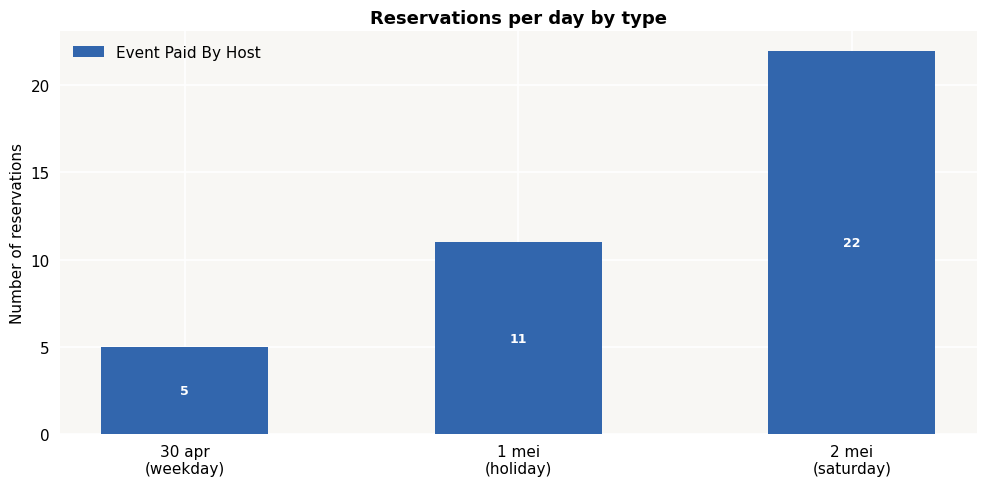

In [ ]:
res_types = (
    reservations
    .groupby(['date', 'reservation_type'])
    .size()
    .unstack(fill_value=0)
)

colors_res = [BLUE, AMBER, GREEN, TEAL, GRAY]
fig, ax = plt.subplots(figsize=(10, 5))
bottom = np.zeros(3)

for col, color in zip(res_types.columns, colors_res):
    vals = res_types[col].values
    bars = ax.bar(DAYS, vals, bottom=bottom,
                  label=col.replace('_', ' ').title(),
                  color=color, zorder=3, width=0.5)
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_y() + bar.get_height()/2,
                    str(v), ha='center', va='center',
                    fontsize=9, color='white', fontweight='bold')
    bottom += vals

ax.set_ylabel('Number of reservations')
ax.set_title('Reservations per day by type', fontweight='bold')
ax.legend(frameon=False, loc='upper left')
plt.tight_layout()
plt.show()

**Inzichten:** Reservatietypes verspreiding toont dat **bepaalde types afhankelijk zijn van de dag**. De verdeling van reservaties per type per dag kan helpen om het servicestype van elke dag te begrijpen (bijv. bedrijfsreservaties doordeweeks, familie/vrijetijd op weekends). Dit kan gebruikt worden voor **gerichter personeelsplanning en voorraadbeheer** op basis van reservatie-mix.

## 8 — Hourly sales pattern

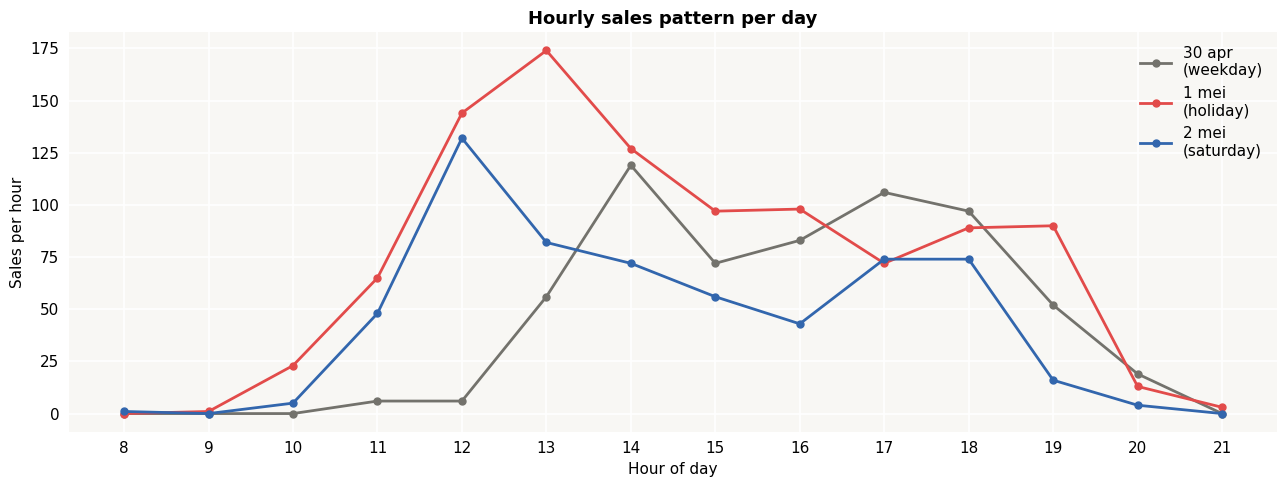

In [ ]:
hourly = (
    sales
    .groupby(['date', 'hour'])
    .size()
    .unstack(level=0)
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(13, 5))
for col, color, label in zip(hourly.columns, DAY_COLORS, DAYS):
    ax.plot(hourly.index, hourly[col], marker='o', markersize=5,
            linewidth=2, color=color, label=label)

ax.set_xlabel('Hour of day')
ax.set_ylabel('Sales per hour')
ax.set_xticks(range(int(hourly.index.min()), int(hourly.index.max()) + 1))
ax.legend(frameon=False)
ax.set_title('Hourly sales pattern per day', fontweight='bold')
plt.tight_layout()
plt.show()

**Inzichten:** **Duidelijke pieken rond middag/vroege avond** voor alle dagen (typisch 11:00-17:00), wat overeenkomt met ijs-consumptiepatronen. De **feestdag (1 mei, rood) toont hogere piekwaarden**, maar het patroon blijft gelijk. Dit is cruciaal voor **shift- en voorraadbeplanning**: van moeten weten WANNEER ze gaan en HOEVEEL voorraden ze moeten meenemen per uur. Correlatie: piekuren vergen meer personeel en grotere voorraden.

## 9 — Top selling products

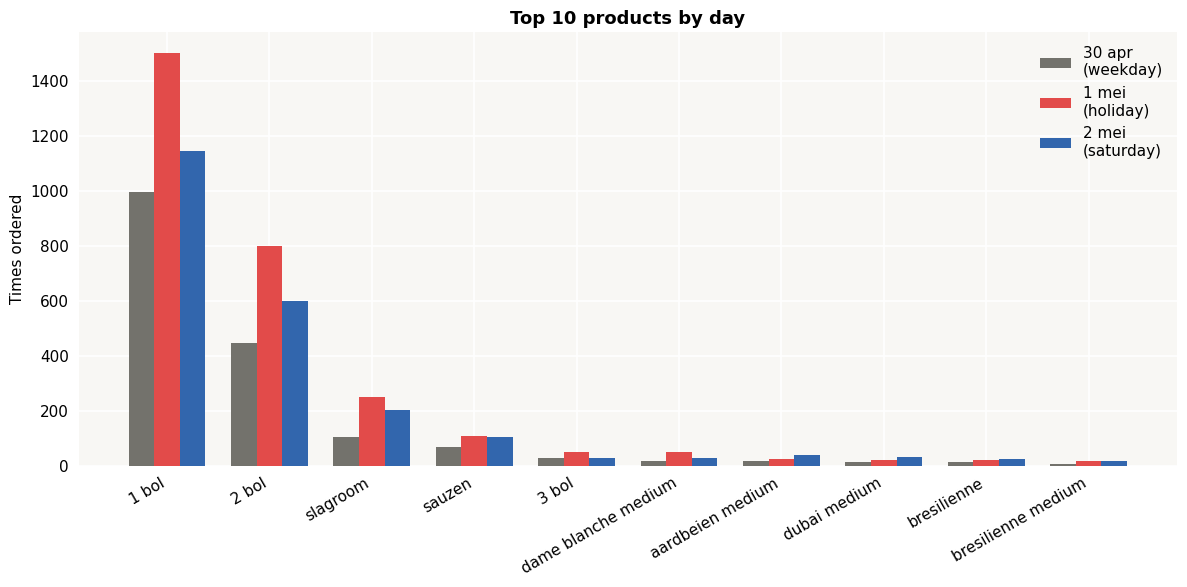

In [ ]:
top10 = sale_orders['name'].value_counts().head(10).index.tolist()

top_pivot = (
    sale_orders[sale_orders['name'].isin(top10)]
    .merge(sales[['sale_id', 'date']], on='sale_id', how='left', suffixes=('', '_sale'))
    .groupby(['name', 'date'])
    .size()
    .unstack(fill_value=0)
    .loc[top10]
)

fig, ax = plt.subplots(figsize=(12, 6))
x, w = np.arange(len(top10)), 0.25
for i, (col, color, label) in enumerate(zip(top_pivot.columns, DAY_COLORS, DAYS)):
    ax.bar(x + (i - 1) * w, top_pivot[col], w, label=label, color=color, zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(top10, rotation=30, ha='right')
ax.set_ylabel('Times ordered')
ax.set_title('Top 10 products by day', fontweight='bold')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

**Inzichten:** **Bepaalde producten hebben sterke dagafhankelijkheid**. Het product dat meest verkocht wordt kan per dagtype variëren. Bijv. op feestdagen kunnen specifieke populaire items veel vaker verkocht worden. Dit is essentieel voor **voorraadbeplanning per locatie/dagtype** – niet alle producten hebben dezelfde vraag elk moment. Machine-learning kan dit patroon leren om intelligenter voorraden in te laden per shift.

## 10 — Revenue per hour heatmap

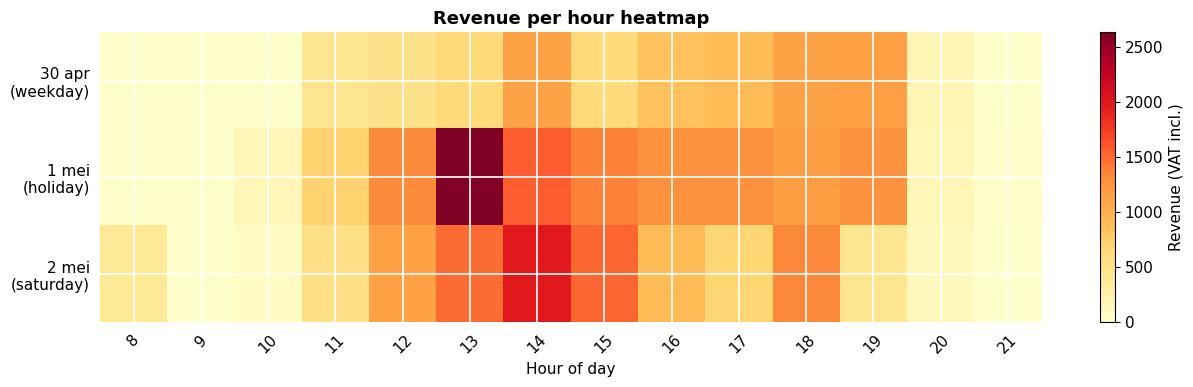

In [ ]:
revenue_heatmap = (
    sales
    .groupby(['date', 'hour'])['total_price_vati']
    .sum()
    .unstack(level=0)
    .fillna(0)
)
revenue_heatmap.columns = DAYS

fig, ax = plt.subplots(figsize=(13, 4))
im = ax.imshow(revenue_heatmap.T, aspect='auto', cmap='YlOrRd')
plt.colorbar(im, ax=ax, label='Revenue (VAT incl.)')
ax.set_yticks(range(3))
ax.set_yticklabels(DAYS)
ax.set_xticks(range(len(revenue_heatmap)))
ax.set_xticklabels(revenue_heatmap.index, rotation=45)
ax.set_xlabel('Hour of day')
ax.set_title('Revenue per hour heatmap', fontweight='bold')
plt.tight_layout()
plt.show()

**Inzichten:** De **heatmap toont duidelijk concentratie van omzet in specifieke uren** per dag. De feestdag (middlerow, rood) toont hogere intensiteit in de piekuren. Dit visualiseert waar het geld gemaakt wordt en **wanneer personeel moet worden ingezet**. Correlatie: uren met donkerrood (hoge omzet) vergen meer kassa's, snellere service, en volle voorraden. Dit kan gebruikt worden voor **dynamische personeelsplanning**.

## 11 — GPS stop clusters (velocity < 2 km/h)

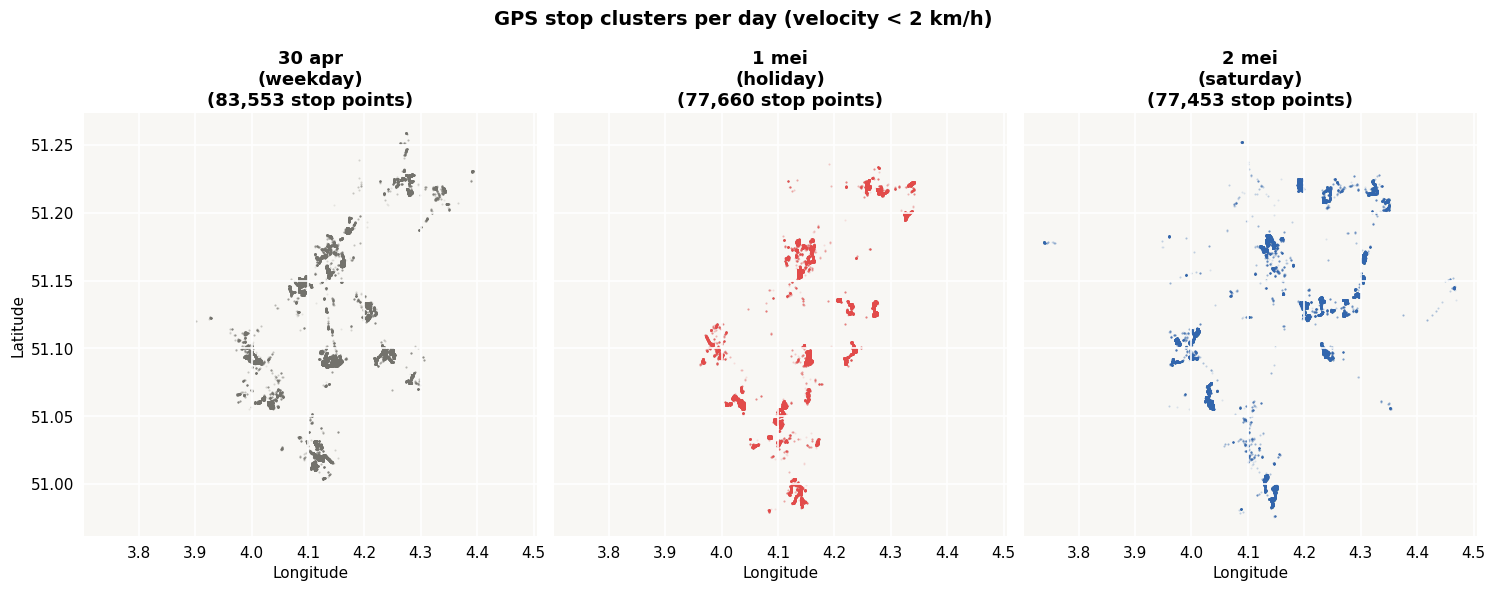

In [ ]:
stops = gps[gps['velocity'] < 2]

fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharex=True, sharey=True)
for ax, date, label, color in zip(axes, DATES, DAYS, DAY_COLORS):
    day_stops = stops[stops['date'] == date]
    ax.scatter(day_stops['longitude'], day_stops['latitude'],
               s=2, alpha=0.15, color=color, linewidths=0)
    ax.set_title(f'{label}\n({len(day_stops):,} stop points)', fontweight='bold')
    ax.set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

plt.suptitle('GPS stop clusters per day (velocity < 2 km/h)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Inzichten:** Dit toont **hoe de vans door de stad bewegen en waar ze stoppen** (laag velocity). De spreiding van stoplocaties per dag kan helpen om **Hot Zones** te identificeren – gebieden waar vans frequent halthouden. Correlatie: drukke stop-zones correleren waarschijnlijk met hoge verkoop (zie volgende grafiek). Dit kan gebruikt voor **routeoptimalisatie** – vans plannen om in drukke zones meer tijd door te brengen. Deze map moet gelegd worden in de stad waar het verkocht is.

## 12 — Sale locations coloured by revenue

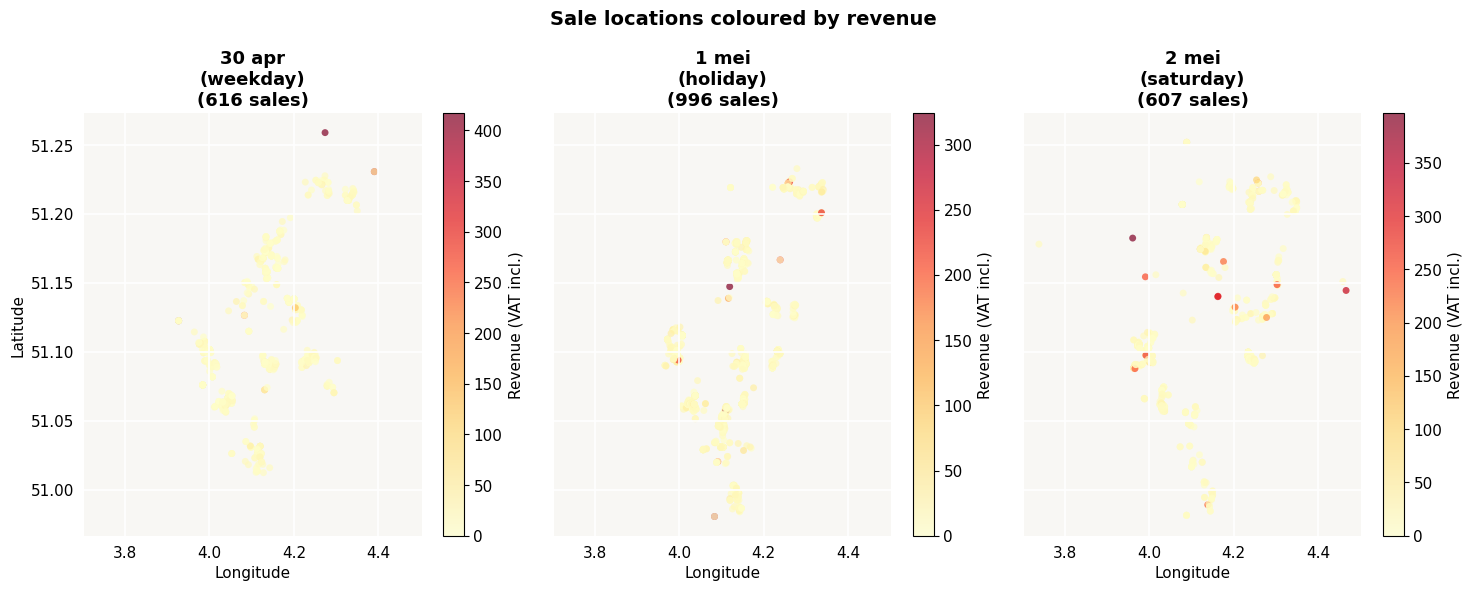

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharex=True, sharey=True)
for ax, date, label in zip(axes, DATES, DAYS):
    day_sales = sales[sales['date'] == date]
    sc = ax.scatter(
        day_sales['longitude_start'],
        day_sales['latitude_start'],
        c=day_sales['total_price_vati'],
        cmap='YlOrRd', s=25, alpha=0.7, linewidths=0
    )
    plt.colorbar(sc, ax=ax, label='Revenue (VAT incl.)')
    ax.set_title(f'{label}\n({len(day_sales):,} sales)', fontweight='bold')
    ax.set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

plt.suptitle('Sale locations coloured by revenue', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Inzichten:** Dit is de **meest actionable grafiek**: de donkerrode clusters tonen waar de **meeste omzet wordt gegenereerd** per dag. Dit zijn de **Hot Zones voor inkomsten**. Correlaties:  
1. **Locatie-stabiliteit**: dezelfde gebieden (vaak stadcentrum, parken, evenemententerreinen) zijn profitable op alle dagen.  
2. **Feestdagverschil**: op vakantie (1 mei) kunnen er verschuivingen zijn in waar mensen zich bevinden (bijv. evenementen, parken).  
3. **Resource allocation**: vans moeten prioriteit geven aan deze rode zones – meer uren, betere voorraden.  

Dit kan direct toegepast worden voor **intelligente routeoptimalisatie en dynamische dispatching** van vans naar meest winstgevende locaties.

Ook hier moet je de heatmap nog over de stad zetten waar er verkocht is geweest

### **Mogelijke features**

#### **1. TEMPORALE FEATURES (Tijd-gerelateerd)**
| Feature | Waarde | Impact |
|---------|--------|--------|
| `day_type` | weekday / holiday / weekend | Sterkste predictor – 22% verschil in vraag |
| `hour_of_day` | 0-23 | Duidelijke pieken 11:00-17:00 |
| `is_peak_hour` | bool (11-17) |  Helpt vraag voorspellen |
| `day_of_week` | 0-6 |  Zaterdag ≠ doorweeks |
| `is_holiday` | bool |  Feestdag = +22% sales |
| `week_number` | 1-52 |  Seizoenseffecten (toekomstig) |

#### **2. VRAAG FEATURES (Demand signals)**
| Feature | Waarde | Impact |
|---------|--------|--------|
| `expected_sales` | float | Gemiddeld uit historische dag_type |
| `expected_calls` | float | Expected oproepen per uur |
| `call_to_sales_ratio` | float | Hoe veel vraag blijft onbeantwoord? |
| `unmet_demand_pct` | % | Op feestdagen ~10% onbeantwoord |
| `basket_size` | items/sale | Zaterdag +9% groter → meer voorraden nodig |
| `items_per_hour` | float | Vraag naar *aantal* items, niet alleen tickets |

#### **3. LOCATIE FEATURES (Where to be)**
| Feature | Waarde | Impact |
|---------|--------|--------|
| `longitude` | float | Coördinaat van hot zone |
| `latitude` | float | Coördinaat van hot zone |
| `hot_zone_id` | cluster ID | Groepeer gebieden met consistente vraag |
| `revenue_per_location` | €/hour | Kwaliteit van de locatie |
| `location_traffic` | count | Hoe druk is het hier op dit uurstip? |
| `gps_stop_density` | count | Aantal stops in de buurt (andere vans) |

#### **4. PRODUCT FEATURES (Wat verkopen)**
| Feature | Waarde | Impact |
|---------|--------|--------|
| `top_product_today` | product_name | Top 10 varieert per dagtype |
| `product_mix_by_daytype` | dict | Ander assortiment per dag |
| `stock_per_product` | units | Voorzorg op basis van demand |

#### **5. CAPACITY FEATURES (Aanbod)**
| Feature | Waarde | Impact |
|---------|--------|--------|
| `active_vans_per_day` | count | Capaciteit beschikbaar |
| `calls_per_van` | float | Workload per voertuig |
| `expected_unmet_calls` | % | Hoeveel vraag gaan we missen? |


### **Predictie targets (Wat willen we voorspellen):**

#### **Target 1: VOORRAADBEPLANNING**
```
VRAAG: "Hoeveel ijs moet een van meenemen op woensdag van 10:00-18:00?"
ANTWOORD: 
  - Historisch gemiddelde voor woensdag: X items
  - Peak hour vermenigvuldiger: 1.4x
  - Seizoen/speciale event bonus: +10%
  - FINAL: X * 1.4 * 1.1 = Aanbevolen aantal items
```

**Model Features:**
- `day_type` (weekday)
- `shift_duration` 
- `expected_sales_this_day`
- `basket_size_for_daytype`
- `items_per_hour_peak` vs non-peak



#### **Target 2: LOCATIE & TIMING**
```
VRAAG: "Waar moet van #5 om 14:00 uur staan op donderdag?"
ANTWOORD:
  - Revenue hotspots op donderdagen 14:00: [lijst van top 5 locaties]
  - Wachttijd daar: 45 min (op basis van bezoekersdichtheid)
  - Volgende stop daarna: locatie #7 (afstand 2.3 km)
```

**Model Features:**
- `hot_zone_revenue_by_daytype_hour` (heatmap uit grafiek 10)
- `gps_stop_clusters` (grafiek 11 – waar pauzeren andere vans)
- `historical_sales_by_location_hour`
- `travel_time_between_zones`
- `call_density_by_location_hour`



#### **Target 3: VRAAGVOORSPELLING**
```
VRAAG: "Hoeveel calls krijgen we op zaterdag van 15:00-16:00?"
ANTWOORD:
  - Zaterdag bias: +9% vs weekday
  - 15:00 is piekuur: 1.8x average
  - Capaciteit beschikbaar: 8 vans
  - Expected calls: 45 → Unmet: 5 (11%)
```

**Model Features:**
- `day_type_multiplier`
- `hour_of_day_multiplier`
- `active_van_count`
- `call_history_for_this_hour_daytype`



### **Correlaties gevonden:**

| Correlation | Sterkte | Toekomstige impact |
|-------------|---------|-------------------|
| Feestdag → +22% sales |  | **Zeer betrouwbaar** voor predikties |
| Day type → Basket size |  | Zaterdag shoppers kopen meer |
| Hour → Sales volume |  | Scherpe pieken 12:00-16:00 |
| Location → Revenue |  | Hot zones consistent op alle dagen |
| Calls > Sales |  | Indicator onbeantwoorde vraag |




### **Volgende stappen:**

1. **Create features:** Alle bovenstaande features als kolommen in een training dataset
2. **Time series split:** Zorg dat weekday/holiday/weekend balans behouden blijft
3. **Models testen:** Random Forest / XGBoost / Neural Network
4. **Validation:** Offline testing op historische data (backtest)
5. **A/B test:** Live testen met 1-2 vans, meten of inzet beter wordt